In [1]:
from itertools import product
import pickle
from tqdm import tqdm, trange

import numpy as np
from numpy.linalg import eigh
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from corner import corner as corner_plot

from scipy import special, stats
from scipy.stats import gaussian_kde, chi2
from scipy.interpolate import RegularGridInterpolator

import os

from local_utils import delaunaytor
from generate_events import MixtureModel

plt.style.use("tableau-colorblind10")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 25
plt.rcParams["text.usetex"] = True

In [2]:
# ninjections=1000000
# strong_selection=1
# nevs=30000
# pop=2
# large_prior=2

# lvk=1

# if lvk:
#     name_file_2d='test_lvk_mock_ev_z_large_prior3'

# else:

#     name_file_2d='test'
#     if strong_selection==1:
#         name_file_2d+='_strong_selection'
#     if pop==2:
#         name_file_2d+='_pop_2'
#     name_file_2d+='_2D_%d_events_5000_samples_%d_injections'%(nevs,ninjections)
#     if large_prior==1:
#         name_file_2d+='_large_prior'
#     elif large_prior==2:
#         name_file_2d+='_large_prior2'
#     file_2d=np.load('runs/data_'+name_file_2d+'/data.npz')

# os.makedirs('plots/run_'+name_file_2d, exist_ok=True)

# observed_events=file_2d['observed_events']
# mins, maxs = observed_events.min(axis=0), observed_events.max(axis=0)
# pad = (maxs - mins) * 0.1
# bounds = list(zip(mins - pad, maxs + pad))
# corners_2d = np.array(list(product(*bounds)))

# if large_prior==1:
#     max_prior=15

# elif large_prior==2:
#     min_prior=-15
#     max_prior=20

# def get_filenames():
#     return ['runs/run_'+name_file_2d]


# def get_covariance(ndim):
#     if ndim == 2:
#         if pop==1:
#             rho1=-0.6
#         elif pop==2:
#             rho1=0
#         sigmax1=4
#         sigmay1=1
#         return np.array([[sigmax1, rho1*np.sqrt(sigmax1*sigmay1)], [rho1*np.sqrt(sigmax1*sigmay1), sigmay1]])
        
#     elif ndim == 3:
#         return np.array([[8, 2, 1], [2, 3, 0.5], [1, 0.5, 2]])
#     elif ndim == 4:
#         return np.array(
#             [[8, 2, 1, 0], [2, 3, 0.5, 0], [1, 0.5, 2, 0.1], [0, 0, 0.1, 1.5]]
#         )
#     else:
#         raise NotImplemented
        
# def get_corners(ndim): 


#     return {
#             2: corners_2d,
#             3: corners_2d,
#             4: np.array([
#                 [-10.10824238,  -5.82820447,  -6.13421008,  -5.14605239],
#                 [-10.10824238,  -5.82820447,  -6.13421008,   4.26606076],
#                 [-10.10824238,  -5.82820447,   6.31054764,  -5.14605239],
#                 [-10.10824238,  -5.82820447,   6.31054764,   4.26606076],
#                 [-10.10824238,   6.63628867,  -6.13421008,  -5.14605239],
#                 [-10.10824238,   6.63628867,  -6.13421008,   4.26606076],
#                 [-10.10824238,   6.63628867,   6.31054764,  -5.14605239],
#                 [-10.10824238,   6.63628867,   6.31054764,   4.26606076],
#                 [  8.74414845,  -5.82820447,  -6.13421008,  -5.14605239],
#                 [  8.74414845,  -5.82820447,  -6.13421008,   4.26606076],
#                 [  8.74414845,  -5.82820447,   6.31054764,  -5.14605239],
#                 [  8.74414845,  -5.82820447,   6.31054764,   4.26606076],
#                 [  8.74414845,   6.63628867,  -6.13421008,  -5.14605239],
#                 [  8.74414845,   6.63628867,  -6.13421008,   4.26606076],
#                 [  8.74414845,   6.63628867,   6.31054764,  -5.14605239],
#                 [  8.74414845,   6.63628867,   6.31054764,   4.26606076],
#             ]),
#     }[ndim]   

observed_events = np.loadtxt('samples.txt')
corners_2d = np.array([[-10,-10],[-10,10],[10,-10],[10,10]])

print(corners_2d)

min_prior=-12
max_prior=8

# def sample_triangulation_prior(ndim, num_samples):
#     corners = get_corners(ndim)
#     mins = corners.min(axis=0)
#     maxs = corners.max(axis=0)

#     n_leaves = np.random.randint(0, 100, size=num_samples)
    
#     return [
#         np.c_[
#             np.vstack([corners, np.random.uniform(mins, maxs, size=(N, ndim))]),
#             np.random.uniform(-6, 9, size=N+corners.shape[0])
#         ]
#         for N in n_leaves
#     ]


[[-10 -10]
 [-10  10]
 [ 10 -10]
 [ 10  10]]


In [3]:
# def get_covariance(ndim):
#     if ndim == 2:
#         if pop==1:
#             rho1=-0.6
#         elif pop==2:
#             rho1=0
#         sigmax1=4
#         sigmay1=1
#         return np.array([[sigmax1, rho1*np.sqrt(sigmax1*sigmay1)], [rho1*np.sqrt(sigmax1*sigmay1), sigmay1]])
#     elif ndim == 3:
#         return np.array([[8, 2, 1], [2, 3, 0.5], [1, 0.5, 2]])
#     elif ndim == 4:
#         return np.array(
#             [[8, 2, 1, 0], [2, 3, 0.5, 0], [1, 0.5, 2, 0.1], [0, 0, 0.1, 1.5]]
#         )
#     else:  # Random positive-definite matrix
#         A = np.random.randn(ndim, ndim)
#         cov = np.dot(A, A.T) + np.eye(ndim)
#         return cov

In [4]:
def triangulation_sizes(backend_file, nsteps, nwalkers):
        
    with open(backend_file, "rb") as f:
        back = pickle.load(f)
    return np.array([
        back.inds["tri"][step, 0, walker].sum()
        for step, walker in product(range(nsteps), range(nwalkers))
    ])

In [5]:
# runs = [1]
nwalkers = 4
nsteps = 1000
nburn = 2000

In [6]:
backend_file = 'backend_events1000_samples10000'

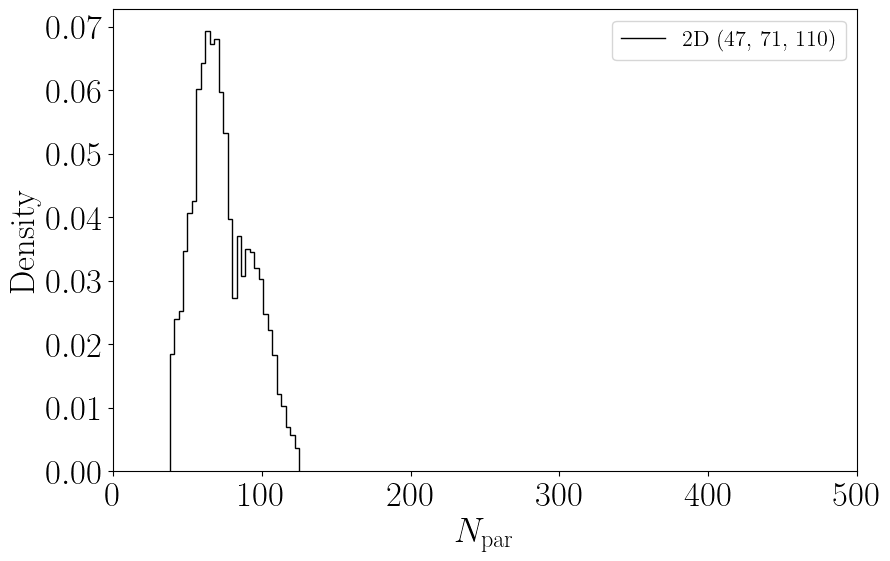

In [7]:
fig, ax = plt.subplots(figsize=(1.2 * 8, 1.2 * 5))
ax.set(
    yscale="linear",
    xlabel=r"$N_{\mathrm{par}}$",
    ylabel="Density",
    xlim=(0, 500),
)

ls = ["-", "--", ":"]

ind=0
ndim=2
tri_sizes = triangulation_sizes(backend_file, nsteps, nwalkers)

tri_sizes = np.stack(tri_sizes).ravel() * (ndim + 1) + 2**ndim + 1 

unique, counts = np.unique(tri_sizes, return_counts=True)
fractions = counts / tri_sizes.size

l, m, h = np.quantile(tri_sizes, [0.05, 0.5, 0.95]).astype(int)

edges = np.concatenate(([unique[0]], unique))
ax.stairs(
    fractions,
    edges, 
    color='black', 
    ls=ls[ind], 
    label=f"{ndim}D ({l}, {m}, {h})"
)

ax.legend()
plt.show()
plt.close()

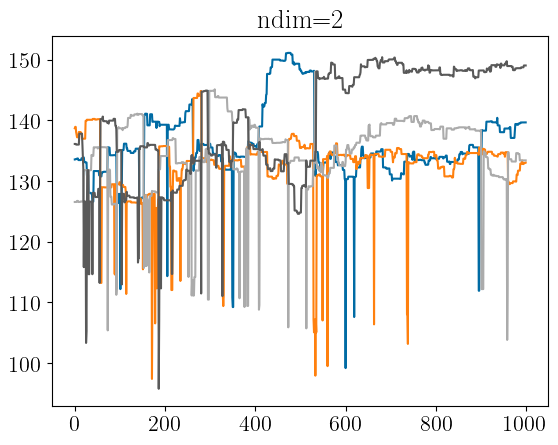

In [8]:
with open(backend_file, "rb") as f:
    back = pickle.load(f)
fig, ax = plt.subplots()
ax.set_rasterized(True)
ax.set(title=f"{ndim=}")
for w in range(nwalkers):
    ax.plot(back.get_log_like()[:, 0, w])
plt.show()
plt.close()

In [9]:
all_triangulations = []

with open(backend_file, "rb") as f:
    back = pickle.load(f)
    triangulations = [
        back.chain["tri"][step, 0, walker][back.inds["tri"][step, 0, walker]]
        for step, walker in product(range(nsteps), range(nwalkers))
    ]

    corner_weights = np.array(
        [
            back.chain["corners"][step, 0, walker]
            for step, walker in product(range(nsteps), range(nwalkers))
        ]
    )

for ind in tqdm(range(len(triangulations))):
    all_triangulations.extend([
        np.vstack([triangulations[ind], np.c_[corners_2d, corner_weights[ind].T]])                
    ])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 102052.43it/s]


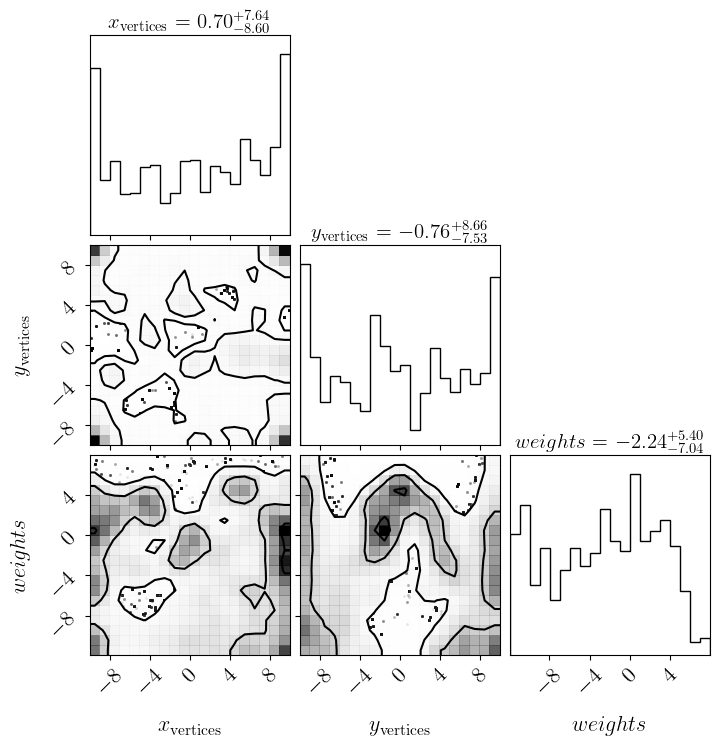

In [10]:
ws = np.hstack([tri[:, -1] for tri in all_triangulations])
vertices = np.vstack([tri[:, :-1] for tri in all_triangulations])    
corner_plot(np.c_[vertices, ws], smooth=True, levels=[0.05, 0.5, 0.95],
            labels=[r"$x_\mathrm{vertices}$", r"$y_\mathrm{vertices}$", r"$weights$"],
            show_titles=True,
            title_kwargs={"fontsize": 15},
           )

plt.show()
plt.close()

In [11]:
def q_flat(x):
    ans=1/(5-(-15))

    return ans


def kl_divergence_kde_p_known_q(p_samples, q_pdf, base=np.e, bandwidth='scott'):
    """
    Estimate KL divergence D_KL(P || Q) where:
      - P is only known via samples (estimated with KDE)
      - Q is known analytically via q_pdf(x)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_pdf (function): function that returns q(x) given x
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated KL divergence D_KL(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde = gaussian_kde(p_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde(p_samples)
    q_vals = q_pdf(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_vals = np.clip(q_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_vals)
    kl = np.mean(log_ratio)

    return kl / np.log(base)


def kl_divergence_kde(p_samples, q_samples, base=np.e, bandwidth='scott'):
    """
    Estimate delta divergence D_delta(P || Q) where:
      - P is only known via samples (estimated with KDE)
      - Q is known analytically via q_pdf(x)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_pdf (function): function that returns q(x) given x
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated delta divergence D_delta(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde_p = gaussian_kde(p_samples, bw_method=bandwidth)

    q_samples = np.asarray(q_samples)
    kde_q = gaussian_kde(q_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde_p(p_samples)
    q_kde_vals = kde_q(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_kde_vals = np.clip(q_kde_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_kde_vals)
    delta = np.mean(log_ratio)

    return delta / np.log(base)

In [12]:
# class ResampleDelaunaytor(delaunaytor.CPUDelaunayInterpolator):
    
#     def re_sample(self, proposals, nmax=5000):
#             volumes = self.volumes()

#             prop_simplices, prop_b = self.simplex_and_barycenters(
#                 proposals
#             )

#             cartesian_coordinates = (
#                     prop_b[..., None]
#                     * self.triangulation.points[self.triangulation.simplices][prop_simplices]
#                 ).sum(axis=1)


#             log_probs=self._interpolate(prop_simplices, prop_b)
            
#             log_to_accept = log_probs - log_probs.max()
    
#             accepted = np.log(np.random.random(size=len(proposals))) < log_to_accept
#             accepted_points = proposals[accepted]

#             return accepted_points[:nmax]

In [13]:
# min_x, min_y = get_corners(ndim).min(axis=0)
# max_x, max_y = get_corners(ndim).max(axis=0)

min_x, min_y = -10, -10
max_x, max_y = 10, 10

x_grid = np.linspace(min_x, max_x, 100)
y_grid = np.linspace(min_y, max_y, 100)


X, Y = np.meshgrid(x_grid, y_grid)
grid = np.c_[X.ravel(), Y.ravel()]

dx = x_grid[1] - x_grid[0]
dy = y_grid[1] - y_grid[0]


# print(log_rate.shape)

print(x_grid)
print(y_grid)

print(grid)

[-10.          -9.7979798   -9.5959596   -9.39393939  -9.19191919
  -8.98989899  -8.78787879  -8.58585859  -8.38383838  -8.18181818
  -7.97979798  -7.77777778  -7.57575758  -7.37373737  -7.17171717
  -6.96969697  -6.76767677  -6.56565657  -6.36363636  -6.16161616
  -5.95959596  -5.75757576  -5.55555556  -5.35353535  -5.15151515
  -4.94949495  -4.74747475  -4.54545455  -4.34343434  -4.14141414
  -3.93939394  -3.73737374  -3.53535354  -3.33333333  -3.13131313
  -2.92929293  -2.72727273  -2.52525253  -2.32323232  -2.12121212
  -1.91919192  -1.71717172  -1.51515152  -1.31313131  -1.11111111
  -0.90909091  -0.70707071  -0.50505051  -0.3030303   -0.1010101
   0.1010101    0.3030303    0.50505051   0.70707071   0.90909091
   1.11111111   1.31313131   1.51515152   1.71717172   1.91919192
   2.12121212   2.32323232   2.52525253   2.72727273   2.92929293
   3.13131313   3.33333333   3.53535354   3.73737374   3.93939394
   4.14141414   4.34343434   4.54545455   4.74747475   4.94949495
   5.151515

In [14]:
# triangulations = all_triangulations[2]
# print(len(triangulations))

selected_tris = range(0, len(all_triangulations), 10)
num_triangulations = len(selected_tris)

log_rate = np.zeros((num_triangulations, grid.shape[0]))
the_num_events = np.zeros(num_triangulations)

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate[ind] = this_delo.interpolate(grid)
    
square_rate = log_rate.reshape(num_triangulations, y_grid.shape[0], x_grid.shape[0])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:00<00:00, 461.84it/s]


In [15]:
median = np.quantile(square_rate, 0.5, axis=0)
low = np.quantile(square_rate, 0.05, axis=0)
high = np.quantile(square_rate, 0.95, axis=0)

In [16]:
def plot_ellipse(mu, cov, ax, n_std=1, **kwargs):
    """
    Plot the ellipse corresponding to an n_std 'sigma' contour
    of a 2D Gaussian with mean mu and covariance cov.
    """
    
    # Eigen-decomposition
    vals, vecs = eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    
    # Chi2 threshold for 2 dof
    chi2_val = chi2.ppf({1:0.68, 2:0.95, 3:0.997}[n_std], df=2)
    
    # Width and height of ellipse
    width, height = 2 * np.sqrt(vals * chi2_val)
    
    # Orientation
    angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    
    ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

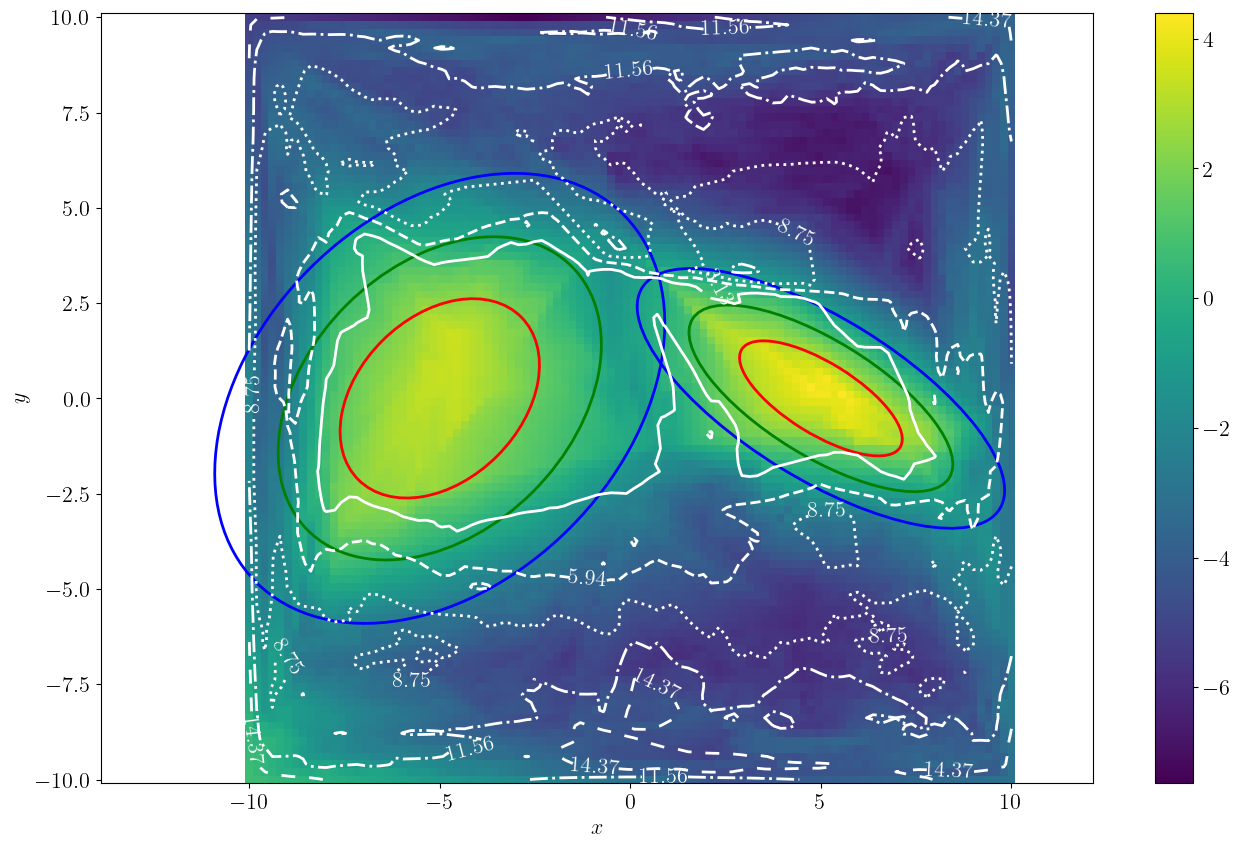

In [17]:
z_indices = [10, 20, 30, 40]

# cov=get_covariance(ndim)
# mean=np.array([-3, 4])
cov1 = np.array([[3,1],[1,3]])
mean1 = np.array([-5,0])
cov2 = np.array([[2,-1],[-1,1]])
mean2 = np.array([5,0])

# print(cov1)

# print(mean)

# print(cov.shape,mean.shape)

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize


fig, ax = plt.subplots(figsize=(16, 10))
c = ax.pcolormesh(x_grid, y_grid, median)    
fig.colorbar(c)


# Calculate the difference
diff = high - low

# Define contour levels (choose appropriate values for your data)
n_contours = min(5, len(linestyles))
levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

# Plot contours with different linestyles
contours = ax.contour(
    x_grid, y_grid, diff, 
    levels=levels, 
    linestyles=linestyles[:n_contours],
    linewidths=2, 
    colors='white'
)



colors = ['r','g','b']

for n, c in zip([1,2,3], colors):
    plot_ellipse(mean1, cov1, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")
    plot_ellipse(mean2, cov2, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")


# Optional: add labels to contours
ax.clabel(contours, fmt="%.2f")

ax.axis('equal')

plt.xlabel('$x$')
plt.ylabel('$y$')

# plt.savefig('plots/run_'+name_file_2d+'/median_with_delta')

plt.show()
plt.close()

In [18]:

x_grid_coarse= np.linspace(min_x, max_x, 20)
y_grid_coarse = np.linspace(min_y, max_y, 20)


X_coarse, Y_coarse = np.meshgrid(x_grid_coarse, y_grid_coarse)
grid_coarse = np.c_[X_coarse.ravel(), Y_coarse.ravel()]

dx_coarse = x_grid_coarse[1] - x_grid_coarse[0]
dy_coarse = y_grid_coarse[1] - y_grid_coarse[0]


In [19]:
log_rate_coarse = np.zeros((num_triangulations, grid_coarse.shape[0]))
the_num_events = np.zeros(num_triangulations)

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_coarse[ind] = this_delo.interpolate(grid_coarse)
    
square_rate_coarse = log_rate_coarse.reshape(num_triangulations, y_grid_coarse.shape[0], x_grid_coarse.shape[0])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:00<00:00, 2110.79it/s]


In [20]:
nsamples_prior=1000
log_rate_prior_coarse = np.zeros((nsamples_prior, grid_coarse.shape[0]))

for i in tqdm(range(nsamples_prior)):

    nleaves_i=np.random.randint(4,101)

    tri_i=np.zeros((nleaves_i+4,3))

    tri_i[:nleaves_i,0]=np.random.uniform(min_x,max_x,nleaves_i)
    tri_i[:nleaves_i,1]=np.random.uniform(min_y,max_y,nleaves_i)

    tri_i[:,2]=np.random.uniform(min_prior,max_prior,nleaves_i+4)

    tri_i[-4,0]=min_x
    tri_i[-4,1]=min_y
 

    tri_i[-3,0]=min_x
    tri_i[-3,1]=max_y

    tri_i[-2,0]=max_x
    tri_i[-2,1]=min_y

    tri_i[-1,0]=max_x
    tri_i[-1,1]=max_y
  
   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior_coarse[i] = this_delo.interpolate(grid_coarse)
    

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1211.28it/s]


In [21]:
# print(all_triangulations[3][0][-8:])

In [22]:
# print(min_x,max_x)
# print(min_y,max_y)
# print(min_z,max_z)

In [23]:
square_rate_prior_coarse = log_rate_prior_coarse.reshape(nsamples_prior, y_grid_coarse.shape[0], x_grid_coarse.shape[0])

In [24]:
kl_divs=np.zeros((len(y_grid_coarse),len(x_grid_coarse)))

for i in tqdm(range(len(y_grid_coarse))):
    for j in range(len(x_grid_coarse)):
            kl_divs[i,j]=kl_divergence_kde(square_rate_coarse[:,i,j],square_rate_prior_coarse[:,i,j])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:14<00:00,  1.39it/s]


In [25]:
interp_kl = RegularGridInterpolator((x_grid_coarse, y_grid_coarse), kl_divs.T, bounds_error=False, fill_value=np.nan)

interp_delta = RegularGridInterpolator((x_grid, y_grid), (low-high).T, bounds_error=False, fill_value=np.nan)

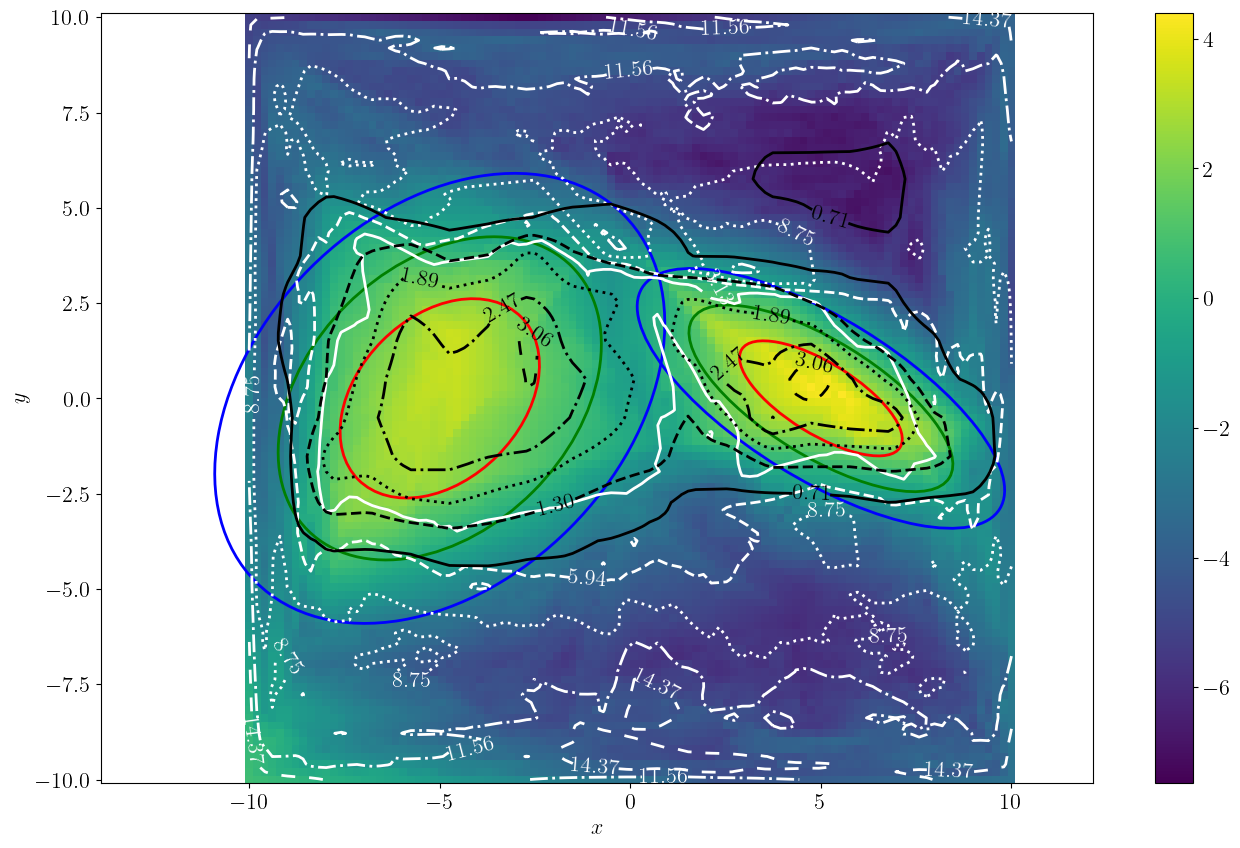

In [26]:
z_indices = [10, 20, 30, 40]

# cov=get_covariance(ndim)
# mean=np.array([-3, 4])
cov1 = np.array([[3,1],[1,3]])
mean1 = np.array([-5,0])
cov2 = np.array([[2,-1],[-1,1]])
mean2 = np.array([5,0])

# print(mean)

# print(cov.shape,mean.shape)

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize


fig, ax = plt.subplots(figsize=(16, 10))
c = ax.pcolormesh(x_grid, y_grid, median)    
fig.colorbar(c)


# Calculate the difference
diff = high - low

# Define contour levels (choose appropriate values for your data)
n_contours = min(5, len(linestyles))
levels_diff = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max
levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

# Plot contours with different linestyles
contours_diff = ax.contour(
    x_grid, y_grid, diff, 
    levels=levels_diff, 
    linestyles=linestyles[:n_contours],
    linewidths=2, 
    colors='white'
)


contours_kl = ax.contour(
    x_grid, y_grid, interp_kl(grid).reshape(len(y_grid),len(x_grid)), 
    levels=levels_kl, 
    linestyles=linestyles[:n_contours],
    linewidths=2, 
    colors='black'
)



colors = ['r','g','b']

for n, c in zip([1,2,3], colors):
    plot_ellipse(mean1, cov1, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")
    plot_ellipse(mean2, cov2, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")

# Optional: add labels to contours
ax.clabel(contours_kl, fmt="%.2f")
ax.clabel(contours_diff, fmt="%.2f")

plt.axis('equal')

plt.xlabel('$x$')
plt.ylabel('$y$')

# plt.savefig('plots/run_'+name_file_2d+'/median_with_delta_and_kl')

plt.show()
plt.close()

/tmp/ipykernel_59521/1584413835.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 1600x1000 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(sc, ax=ax0)


(np.float64(-10.995519366281957),
 np.float64(10.995587171352192),
 np.float64(-10.9937425316523),
 np.float64(10.989976958779922))

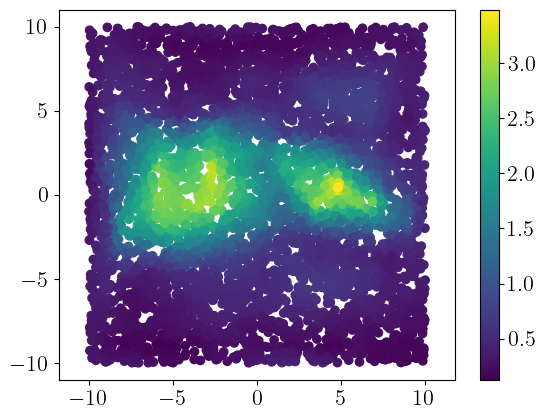

In [27]:
fig0,ax0=plt.subplots()

samples_try=np.zeros((5000,2))

# samples_try[:,0]=5
# samples_try[:,1]=np.random.uniform(min_x,max_x,5000)
# samples_try[:,2]=np.random.uniform(min_z,max_z,5000)


samples_try[:,0]=np.random.uniform(min_x,max_x,5000)
samples_try[:,1]=np.random.uniform(min_x,max_x,5000)



sc=ax0.scatter(samples_try[:,0],samples_try[:,1],c=interp_kl(samples_try))

fig.colorbar(sc, ax=ax0)

plt.axis('equal')

plt.show()
plt.close()

In [28]:
kl_levels = np.linspace(0, np.amax(kl_divs), 20)[1:-1]
xmin_kl={}
xmax_kl={}
ymin_kl={}
ymax_kl={}

for kl in kl_levels:
    ndraw=10000000
    proposals=np.zeros((ndraw,2))

    proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
    proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)


    inds_proposal_keep=np.argwhere(interp_kl(proposals)>kl-0.02)[:,0]

    xmin_kl[kl]=np.amin(proposals[inds_proposal_keep,0])
    xmax_kl[kl]=np.amax(proposals[inds_proposal_keep,0])
    ymin_kl[kl]=np.amin(proposals[inds_proposal_keep,1])
    ymax_kl[kl]=np.amax(proposals[inds_proposal_keep,1])

In [29]:
samples_per_tri = 1_000
num_triangulations = len(selected_tris)
ndraw=10000


ints_kl={}
# volume = np.prod(get_corners(ndim).max(axis=0) - get_corners(ndim).min(axis=0))
volume = np.prod(corners_2d.max(axis=0) - corners_2d.min(axis=0))
print(kl_levels)
for kl in kl_levels:

    nprop=0
    nkeep=0
    nkeep_old=0

    print(kl)

    proposals=np.zeros((ndraw,2))

    while nkeep<ndraw:
        

        new_points=np.zeros((ndraw-nkeep,2))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
   


        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points)>kl)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)

    print(len(proposals))


    frac_kept = nkeep / nprop


    ints_kl[kl]=np.zeros(num_triangulations)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        # samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_kl[kl], xmax_kl[kl], ymin_kl[kl], ymax_kl[kl], zmin_kl[kl], zmax_kl[kl], interp, kl, weight_fun=None)
        # # print(len(samples_ind))
        # if len(samples_ind)<samples_per_tri:
        #     inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
        #     samples_ind=samples_ind[inds_to_use]
        
        mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        # frac_kept = len(inds_proposal_keep) / len(proposals)
        
        # print(mean_fx,frac_kept,volume)
        ints_kl[kl][ind]= mean_fx * frac_kept * volume
        # ints_kl[kl][ind]= mean_fx * volume

[0.19211335 0.3842267  0.57634005 0.7684534  0.96056675 1.1526801
 1.34479345 1.53690679 1.72902014 1.92113349 2.11324684 2.30536019
 2.49747354 2.68958689 2.88170024 3.07381359 3.26592694 3.45804029]
0.19211334935416224
10000


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:03<00:00, 260.38it/s]


0.3842266987083245
10000


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:02<00:00, 276.26it/s]


0.5763400480624867
10000


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:02<00:00, 380.54it/s]


3.2659269390207584
10000


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:01<00:00, 461.59it/s]


3.4580402883749204
10000


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:01<00:00, 465.71it/s]


In [30]:
true_quantities_kl = np.zeros(len(kl_levels))

true_N = 1000
# gt_distro = stats.multivariate_normal(mean, cov)
gt_distro = MixtureModel(
        dist1 = stats.multivariate_normal(mean1, cov1),
        dist2 = stats.multivariate_normal(mean2, cov2),
        weight1 = 0.5,
    )

# volume = np.prod(get_corners(ndim).max(axis=0) - get_corners(ndim).min(axis=0))
volume = np.prod(corners_2d.max(axis=0) - corners_2d.min(axis=0))
for kl_ind, kl_level in enumerate(kl_levels):

    nprop=0
    nkeep=0
    nkeep_old=0

    print(kl_level)

    proposals=np.zeros((ndraw,2))

    while nkeep<ndraw:
        

        new_points=np.zeros((ndraw-nkeep,2))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
     


        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points)>kl_level)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)

    print(len(proposals))


    frac_kept = nkeep / nprop  
        
    # re_samples = this_delo.re_sample(proposals[inds_proposal_keep], nmax=samples_per_tri)
    
    mean_fx = gt_distro.pdf(proposals).mean()
    # frac_kept = len(inds_proposal_keep) / len(proposals)
    
    true_quantities_kl[kl_ind] = true_N * mean_fx * frac_kept * volume

0.19211334935416224
10000
0.3842266987083245
10000
0.5763400480624867
10000
0.768453397416649
10000
0.9605667467708112
10000
1.1526800961249735
10000
1.3447934454791357
10000
1.536906794833298
10000
1.7290201441874602
10000
1.9211334935416224
10000
2.1132468428957845
10000
2.305360192249947
10000
2.4974735416041094
10000
2.6895868909582714
10000
2.8817002403124334
10000
3.073813589666596
10000
3.2659269390207584
10000
3.4580402883749204
10000


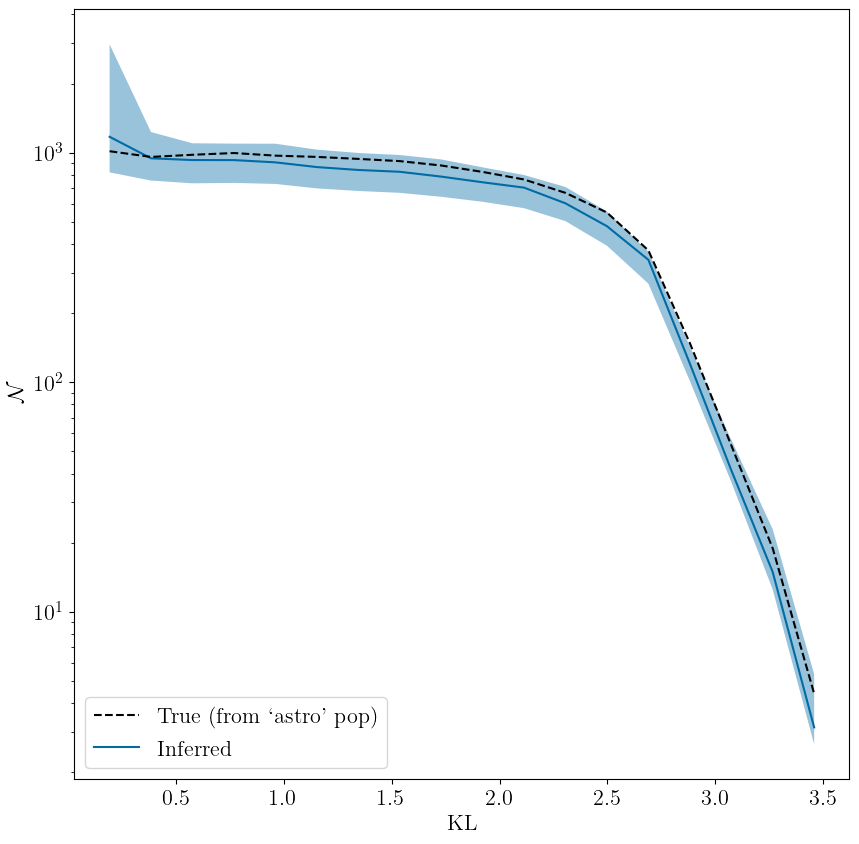

In [32]:
fig, ax = plt.subplots(figsize=(10,10))


median = [ np.median(ints_kl[kl]) for kl  in kl_levels]
low = [ np.quantile(ints_kl[kl], 0.05) for kl  in kl_levels]
high = [ np.quantile(ints_kl[kl], 0.95) for kl  in kl_levels]


ax.plot(kl_levels, true_quantities_kl, "--", color="black", zorder=3, label="True (from `astro' pop)")
ax.plot(kl_levels, median, label='Inferred')
ax.fill_between(kl_levels, low, high, alpha=0.4)

ax.set_xlabel('KL')
ax.set_ylabel('$\\mathcal{N}$')
ax.set_yscale('log')

ax.legend(loc='lower left')
# plt.savefig('plots/run_'+name_file_2d+'/integrated_rate_kl')
plt.show()
plt.close()

In [33]:

delta_levels = np.linspace(-np.amax(diff), -np.amin(diff), 20)[:-1]
xmin_delta={}
xmax_delta={}
ymin_delta={}
ymax_delta={}

for delta in delta_levels:
    ndraw=10000000
    proposals=np.zeros((ndraw,2))

    proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
    proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
    

    inds_proposal_keep=np.argwhere(interp_delta(proposals)>delta-0.02)[:,0]

    xmin_delta[delta]=np.amin(proposals[inds_proposal_keep,0])
    xmax_delta[delta]=np.amax(proposals[inds_proposal_keep,0])
    ymin_delta[delta]=np.amin(proposals[inds_proposal_keep,1])
    ymax_delta[delta]=np.amax(proposals[inds_proposal_keep,1])


    

In [34]:
samples_per_tri = 1_000


# print(delta)
ndraw=10000


# volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))
volume = np.prod(corners_2d.max(axis=0) - corners_2d.min(axis=0))

ints_delta={}
for delta in np.flip(delta_levels):

    nprop=0
    nkeep=0
    nkeep_old=0

    print(delta)

    proposals=np.zeros((ndraw,2))

    while nkeep<ndraw:
        

        new_points=np.zeros((ndraw-nkeep,2))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
     


        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_delta(new_points)>delta)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)

    print(len(proposals))


    frac_kept = nkeep / nprop

    selected_tris=np.random.choice(len(all_triangulations), size=num_triangulations, replace=False)

    ints_delta[delta]=np.zeros(num_triangulations)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        # samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_delta[delta], xmax_delta[delta], ymin_delta[delta], ymax_delta[delta], zmin_delta[delta], zmax_delta[delta], interp_delta, delta, weight_fun=None)
        # # print(len(samples_ind))
        # if len(samples_ind)<samples_per_tri:
        #     inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
        #     samples_ind=samples_ind[inds_to_use]
        
        mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        
        
        # print(mean_fx,frac_kept,volume)
        ints_delta[delta][ind]= mean_fx * frac_kept * volume
        # ints_kl[kl][ind]= mean_fx * volume
    # print(np.exp(-6)* frac_kept * volume,np.amax(np.exp(this_delo.interpolate(samples_ind))),np.amax(np.exp(this_delo.interpolate(samples_ind)))*frac_kept * volume)

-1.2034428730004603
10000


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:02<00:00, 359.90it/s]


-2.0911343482750127
10000


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:02<00:00, 338.52it/s]


-2.9788258235495633
10000


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:03<00:00, 261.82it/s]


-16.294197952667837
10000


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:02<00:00, 267.24it/s]


-17.181889427942387
10000


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:02<00:00, 270.53it/s]


In [35]:
true_quantities = np.zeros(len(delta_levels))

# volume = np.prod(get_corners(ndim).max(axis=0) - get_corners(ndim).min(axis=0))
volume = np.prod(corners_2d.max(axis=0) - corners_2d.min(axis=0))

for delta_ind, delta_level in enumerate(delta_levels):

    # proposals=np.zeros((ndraw*100,3))

    # proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
    # proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
    # proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)


    # inds_proposal_keep=np.argwhere( interp_delta(proposals) > delta_level)[:,0]  

    # print(len(inds_proposal_keep))  

    nprop=0
    nkeep=0
    nkeep_old=0

    print(delta_level)

    proposals=np.zeros((ndraw,2))

    while nkeep<ndraw:
        

        new_points=np.zeros((ndraw-nkeep,2))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
       

        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_delta(new_points)>delta_level)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)
    
    frac_kept = nkeep / nprop
    # re_samples = this_delo.re_sample(proposals[inds_proposal_keep], nmax=samples_per_tri)
    
    mean_fx = gt_distro.pdf(proposals).mean()
    # frac_kept = len(inds_proposal_keep) / len(proposals)
    
    true_quantities[delta_ind] = true_N * mean_fx * frac_kept * volume

-17.181889427942387
-16.294197952667837
-15.406506477393284
-14.518815002118732
-13.631123526844181
-12.74343205156963
-11.855740576295078
-10.968049101020526
-10.080357625745975
-9.192666150471425
-8.304974675196872
-7.41728319992232
-6.529591724647769
-5.641900249373219
-4.754208774098666
-3.866517298824114
-2.9788258235495633
-2.0911343482750127
-1.2034428730004603


<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_59521/1907073160.py:14: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel('$\Delta$')


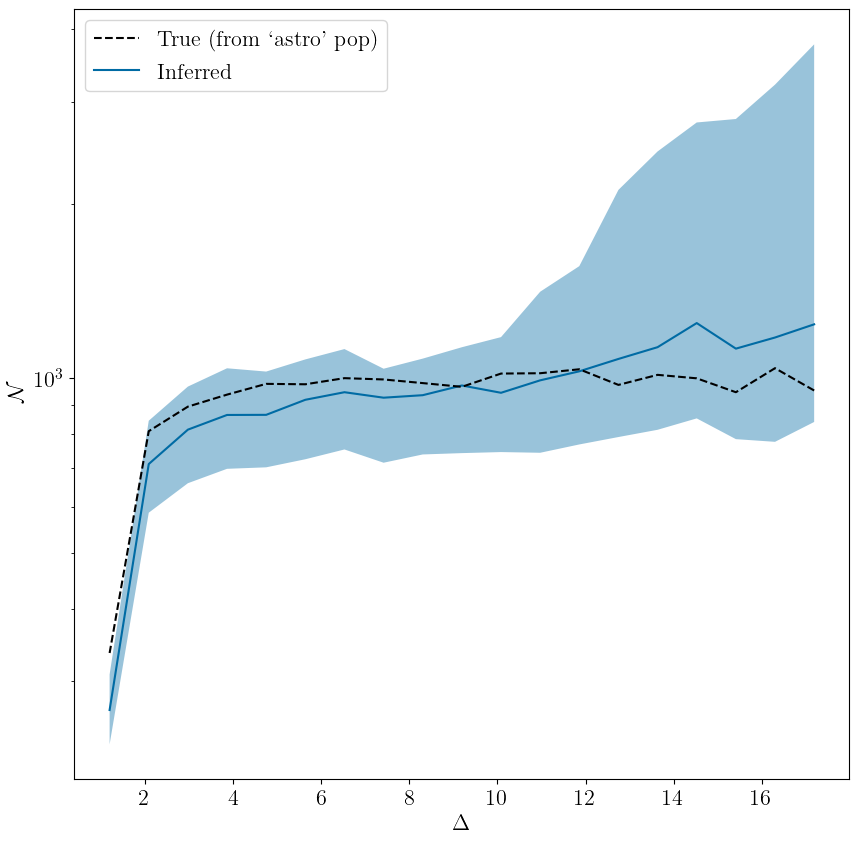

In [36]:
fig, ax = plt.subplots(figsize=(10,10))


median = [ np.median(ints_delta[delta]) for delta  in delta_levels]
low = [ np.quantile(ints_delta[delta], 0.05) for delta  in delta_levels]
high = [ np.quantile(ints_delta[delta], 0.95) for delta  in delta_levels]


ax.plot(-delta_levels, true_quantities, "--", color="black", zorder=3, label="True (from `astro' pop)")
ax.plot(-delta_levels, median, label='Inferred')
ax.fill_between(-delta_levels, low, high, alpha=0.4)

# np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
ax.set_xlabel('$\Delta$')
ax.set_ylabel('$\\mathcal{N}$')
ax.set_yscale('log')

ax.legend(loc='upper left')
# plt.savefig('plots/run_'+name_file_2d+'/integrated_rate_delta')
plt.show()
plt.close()

(array([  14.,   37.,   53.,   64.,  152.,  298.,  436.,  867., 1297.,
        1782.]),
 array([-65.57606545, -58.5834427 , -51.59081994, -44.59819718,
        -37.60557442, -30.61295167, -23.62032891, -16.62770615,
         -9.6350834 ,  -2.64246064,   4.35016212]),
 <BarContainer object of 10 artists>)

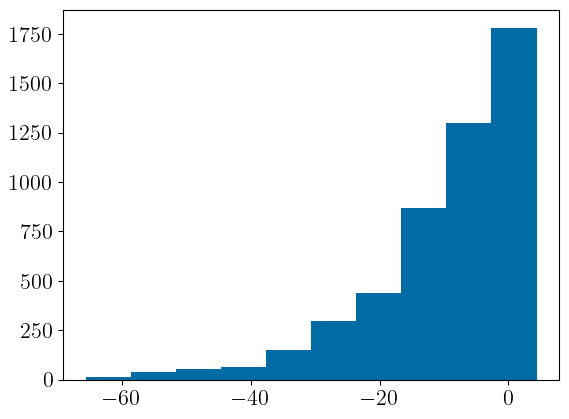

In [37]:
# plt.hist(np.log(true_N*gt_distro.pdf(samples_try)))

In [ ]:
# dm_levels=np.linspace(0.5,10,30)

# samples_per_tri = 1_000

# # print(delta)
# # ndraw=10000000
# # proposals=np.zeros((ndraw,3))

# # proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
# # proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
# # proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

# # volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))

# Sigma_inv = np.linalg.inv(cov)


# ints_dm={}

# # samples_gauss = gt_distro.rvs(ndraw)
# # pdfs_gauss=gt_distro.pdf(samples_gauss)

# ndraw=5000


# proposals=np.zeros((ndraw,3))

# proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
# proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)


# volume = np.prod(get_corners(ndim).max(axis=0) - get_corners(ndim).min(axis=0))


# for dm in dm_levels:


#     nprop=0
#     nkeep=0
#     nkeep_old=0

#     print(dm)

#     proposals=np.zeros((ndraw,2))

#     while nkeep<ndraw:
        
#         # print(nkeep)

#         new_points=np.zeros((ndraw-nkeep,2))
#         new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
#         new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)



#         nprop+=ndraw-nkeep


#         diff = new_points - mean
#         d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)
        
#         inds_proposal_keep=np.argwhere(d2 <= dm**2)[:,0]
#         # frac_kept = len(inds_proposal_keep) / len(proposals)

#         nkeep+=len(inds_proposal_keep)

#         proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

#         nkeep_old+=len(inds_proposal_keep)


#     frac_kept=nkeep/nprop
    
#     # # Compute squared Mahalanobis distances
#     # diff = proposals - mean
#     # d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)

#     # # Fixed threshold
   
#     # mask = d2 <= dm**2    # keep points inside ellipsoid
#     # samples_ind = proposals[mask]

#     # # print(dm)
    
#     # # inds_proposal_keep=np.argwhere(interp_delta(proposals)>delta)[:,0]
#     # frac_kept = np.sum(mask)/ len(proposals)

#     # # print(np.sum(mask))


#     selected_tris=np.random.choice(len(triangulations), size=num_triangulations, replace=False)

#     ints_dm[dm]=np.zeros(num_triangulations)

#     for ind, tri_ind in enumerate(tqdm(selected_tris)):
#         this_delo = delaunaytor.CPUDelaunayInterpolator()
#         this_delo.triangulate(triangulations[tri_ind])
#         # samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_delta[delta], xmax_delta[delta], ymin_delta[delta], ymax_delta[delta], zmin_delta[delta], zmax_delta[delta], interp_delta, delta, weight_fun=None)
#         # # print(len(samples_ind))
#         # if len(samples_ind)<samples_per_tri:
#         #     inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
#         #     samples_ind=samples_ind[inds_to_use]
        
#         mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        
        
#         # print(mean_fx,frac_kept,volume)
#         ints_dm[dm][ind]= mean_fx * frac_kept * volume
#         # ints_kl[kl][ind]= mean_fx * volume
#     # print(np.exp(-6)* frac_kept * volume,np.amax(np.exp(this_delo.interpolate(samples_ind))),np.amax(np.exp(this_delo.interpolate(samples_ind)))*frac_kept * volume)


In [ ]:
# true_quantities_dm = np.zeros(len(dm_levels))

# ndim = 3
# true_N = 1000
# gt_distro = stats.multivariate_normal(mean, cov)


# ndraw=50000


# proposals=np.zeros((ndraw,3))

# proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
# proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
# proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

# volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))

# for dm_ind, dm_level in enumerate(dm_levels):

#     # # proposals=np.zeros((ndraw*100,3))

#     # # proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
#     # # proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
#     # # proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

#     # diff = proposals - mean
#     # d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)

#     # # Fixed threshold
   
#     # mask = d2 <= dm_level**2    # keep points inside ellipsoid
#     # samples_ind = proposals[mask]

#     # # print(dm)
    
#     # # inds_proposal_keep=np.argwhere(interp_delta(proposals)>delta)[:,0]
#     # frac_kept = np.sum(mask)/ len(proposals)

#     nprop=0
#     nkeep=0
#     nkeep_old=0

#     print(dm)

#     proposals=np.zeros((ndraw,3))

#     while nkeep<ndraw:
        
#         # print(nkeep)

#         new_points=np.zeros((ndraw-nkeep,3))
#         new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
#         new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
#         new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)


#         nprop+=ndraw-nkeep


#         diff = new_points - mean
#         d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)
        
#         inds_proposal_keep=np.argwhere(d2 <= dm_level**2)[:,0]
#         # frac_kept = len(inds_proposal_keep) / len(proposals)

#         nkeep+=len(inds_proposal_keep)

#         proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

#         nkeep_old+=len(inds_proposal_keep)


#     frac_kept=nkeep/nprop

    

#     print(np.sum(mask))
        
#     # re_samples = this_delo.re_sample(proposals[inds_proposal_keep], nmax=samples_per_tri)
    
#     mean_fx = gt_distro.pdf(proposals).mean()
#     # frac_kept = np.sum(mask) / len(proposals)
#     true_quantities_dm[dm_ind] = true_N * mean_fx * frac_kept * volume

In [ ]:
# fig, ax = plt.subplots()


# median = [ np.median(ints_dm[dm]) for dm  in dm_levels]
# low = [ np.quantile(ints_dm[dm], 0.05) for dm  in dm_levels]
# high = [ np.quantile(ints_dm[dm], 0.95) for dm  in dm_levels]


# ax.plot(dm_levels, true_quantities_dm, "--", color="black", zorder=3, markerfacecolor="white")
# ax.errorbar(dm_levels, median)
# ax.fill_between(dm_levels, low, high, alpha=0.4)

# # np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
# plt.yscale('log')
# plt.savefig("3D_volume_delta")


# print(true_quantities_dm)

In [ ]:
# kl_levels = np.linspace(0, np.amax(kl_divs), 7)[:-1]
# xmin_kl={}
# xmax_kl={}
# ymin_kl={}
# ymax_kl={}

# for kl in kl_levels:
#     ndraw=10000000
#     proposals=np.zeros((ndraw,2))

#     proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
#     proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
    


#     inds_proposal_keep=np.argwhere(interp_kl(proposals)>kl-0.02)[:,0]

#     xmin_kl[kl]=np.amin(proposals[inds_proposal_keep,0])
#     xmax_kl[kl]=np.amax(proposals[inds_proposal_keep,0])
#     ymin_kl[kl]=np.amin(proposals[inds_proposal_keep,1])
#     ymax_kl[kl]=np.amax(proposals[inds_proposal_keep,1])
   


    

In [ ]:
# delta_levels=np.linspace(-np.amax(diff), -np.amin(diff), 7)[:-1]
# xmin_delta={}
# xmax_delta={}
# ymin_delta={}
# ymax_delta={}

# for delta in delta_levels:
#     ndraw=10000000
#     proposals=np.zeros((ndraw,2))

#     proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
#     proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
    


#     inds_proposal_keep=np.argwhere(interp_delta(proposals)>delta-0.02)[:,0]

#     xmin_delta[delta]=np.amin(proposals[inds_proposal_keep,0])
#     xmax_delta[delta]=np.amax(proposals[inds_proposal_keep,0])
#     ymin_delta[delta]=np.amin(proposals[inds_proposal_keep,1])
#     ymax_delta[delta]=np.amax(proposals[inds_proposal_keep,1])
   


    

In [ ]:
# from scipy.stats import spearmanr
# from ennemi import estimate_corr

# # samples_kl={}
# spearmans_2d_kl={}
# mic_2d_kl={}

# spearmans_2d_kl_box={}
# mic_2d_kl_box={}
# for kl in kl_levels:

#     print(kl)
#     # ndraw=10000000
#     # proposals=np.zeros((ndraw,2))

#     # proposals[:,0]=np.random.uniform(xmin_kl[kl],xmax_kl[kl],ndraw)
#     # proposals[:,1]=np.random.uniform(ymin_kl[kl],ymax_kl[kl],ndraw)


#     # inds_proposal_keep=np.argwhere(interp(proposals)>kl)[:,0]

#     # proposals[inds_proposal_keep]


#     samples_per_tri = 1000
#     num_triangulations=1000
#     selected_tris=np.random.choice(len(triangulations), size=num_triangulations, replace=False)


#     # samples_kl[kl] = np.zeros((num_triangulations, samples_per_tri, 2))

#     spearmans_2d_kl[kl]=np.zeros(num_triangulations)
#     mic_2d_kl[kl]=np.zeros(num_triangulations)

#     spearmans_2d_kl_box[kl]=np.zeros(num_triangulations)
#     mic_2d_kl_box[kl]=np.zeros(num_triangulations)

#     for ind, tri_ind in enumerate(tqdm(selected_tris)):
#         this_delo = delaunaytor.CPUDelaunayInterpolator()
#         this_delo.triangulate(triangulations[tri_ind])
#         # samples_ind=this_delo.re_sample(proposals[inds_proposal_keep],nmax=samples_per_tri)
#         # print(len(samples_ind))
#         samples_ind=this_delo.condition_sample(samples_per_tri, xmin_kl[kl], xmax_kl[kl], ymin_kl[kl], ymax_kl[kl], interp_kl, kl, weight_fun=None)
#         if len(samples_ind)<samples_per_tri:
#             print('have to add:',len(samples_ind))
#             inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
#             samples_ind=samples_ind[inds_to_use]
#         # samples_kl[kl][ind] = samples_ind
#         # print(spearmanr(samples_ind),spearmans_kl[kl][ind])
#         spearmans_2d_kl[kl][ind]=spearmanr(samples_ind).statistic

#         # kde2d=gaussian_kde(samples_ind.T, bw_method='scott')
#         # kdex=gaussian_kde(samples_ind[:,0], bw_method='scott')
#         # kdey=gaussian_kde(samples_ind[:,1], bw_method='scott')

#         # mi_ind=max(0,np.mean(np.log(kde2d(samples_ind.T)/(kdex(samples_ind[:,0])*kdey(samples_ind[:,1])))))

#         # mic_kl[kl][ind]=np.sqrt(1.-np.exp(-2*mi_ind))

#         mic_2d_kl[kl][ind]=estimate_corr(samples_ind[:,1],samples_ind[:,0])

#         proposals=this_delo.condition_sample(samples_per_tri, xmin_kl[kl], xmax_kl[kl], ymin_kl[kl], ymax_kl[kl],interp_kl, -1, weight_fun=None)

        

#         spearmans_2d_kl_box[kl][ind]=spearmanr(proposals).statistic
#         mic_2d_kl_box[kl][ind]=estimate_corr(proposals[:,1],proposals[:,0])

#         # if np.isnan(mic_kl[kl][ind]):
#         #     print('nan:',mi_ind)


#     #     if ind<10:
            
#     #         plt.figure()
#     #         plt.scatter(samples_ind[:,0],samples_ind[:,1])

#     #         # print(len(samples_ind))

#     # plt.show()
            

In [ ]:
# from scipy.stats import spearmanr
# from ennemi import estimate_corr

# # samples_kl={}
# spearmans_2d_delta={}
# mic_2d_delta={}

# spearmans_2d_delta_box={}
# mic_2d_delta_box={}

# print(delta_levels)
# print(xmin_delta)
# for delta in delta_levels:

#     print(delta)
#     # ndraw=10000000
#     # proposals=np.zeros((ndraw,2))

#     # proposals[:,0]=np.random.uniform(xmin_kl[kl],xmax_kl[kl],ndraw)
#     # proposals[:,1]=np.random.uniform(ymin_kl[kl],ymax_kl[kl],ndraw)


#     # inds_proposal_keep=np.argwhere(interp(proposals)>kl)[:,0]

#     # proposals[inds_proposal_keep]


#     samples_per_tri = 1000
#     num_triangulations=1000
#     selected_tris=np.random.choice(len(triangulations), size=num_triangulations, replace=False)


#     # samples_kl[kl] = np.zeros((num_triangulations, samples_per_tri, 2))

#     spearmans_2d_delta[delta]=np.zeros(num_triangulations)
#     mic_2d_delta[delta]=np.zeros(num_triangulations)

#     spearmans_2d_delta_box[delta]=np.zeros(num_triangulations)
#     mic_2d_delta_box[delta]=np.zeros(num_triangulations)

#     for ind, tri_ind in enumerate(tqdm(selected_tris)):
#         this_delo = delaunaytor.CPUDelaunayInterpolator()
#         this_delo.triangulate(triangulations[tri_ind])
#         # samples_ind=this_delo.re_sample(proposals[inds_proposal_keep],nmax=samples_per_tri)
#         # print(len(samples_ind))
#         samples_ind=this_delo.condition_sample(samples_per_tri, xmin_delta[delta], xmax_delta[delta], ymin_delta[delta], ymax_delta[delta], interp_delta, delta, weight_fun=None)
#         if len(samples_ind)<samples_per_tri:
#             print('have to add:',len(samples_ind))
#             inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
#             samples_ind=samples_ind[inds_to_use]
#         # samples_kl[kl][ind] = samples_ind
#         # print(spearmanr(samples_ind),spearmans_kl[kl][ind])
#         spearmans_2d_delta[delta][ind]=spearmanr(samples_ind).statistic

#         # kde2d=gaussian_kde(samples_ind.T, bw_method='scott')
#         # kdex=gaussian_kde(samples_ind[:,0], bw_method='scott')
#         # kdey=gaussian_kde(samples_ind[:,1], bw_method='scott')

#         # mi_ind=max(0,np.mean(np.log(kde2d(samples_ind.T)/(kdex(samples_ind[:,0])*kdey(samples_ind[:,1])))))

#         # mic_kl[kl][ind]=np.sqrt(1.-np.exp(-2*mi_ind))

#         mic_2d_delta[delta][ind]=estimate_corr(samples_ind[:,1],samples_ind[:,0])

#         proposals=this_delo.condition_sample(samples_per_tri, xmin_delta[delta], xmax_delta[delta], ymin_delta[delta], ymax_delta[delta],interp_delta, -1000, weight_fun=None)

        

#         spearmans_2d_delta_box[delta][ind]=spearmanr(proposals).statistic
#         mic_2d_delta_box[delta][ind]=estimate_corr(proposals[:,1],proposals[:,0])

#         # if np.isnan(mic_kl[kl][ind]):
#         #     print('nan:',mi_ind)


#     #     if ind<10:
            
#     #         plt.figure()
#     #         plt.scatter(samples_ind[:,0],samples_ind[:,1])

#     #         # print(len(samples_ind))

#     # plt.show()
            

In [ ]:

# nsamples_prior=2000
# log_rate_prior = np.zeros((nsamples_prior, grid.shape[0]))

# kl_divs_prior=np.zeros((len(x_grid),len(y_grid)))

# samples_per_tri=1000

# spearmans_prior=np.zeros(nsamples_prior)

# mic_prior=np.zeros(nsamples_prior)


# for i in tqdm(range(nsamples_prior)):

#     nleaves_i=np.random.randint(4,101)

#     tri_i=np.zeros((nleaves_i+8,3))

#     tri_i[:nleaves_i,0]=np.random.uniform(min_x,max_x,nleaves_i)
#     tri_i[:nleaves_i,1]=np.random.uniform(min_y,max_y,nleaves_i)

#     tri_i[:,2]=np.random.uniform(min_prior,max_prior,nleaves_i+8)

#     tri_i[-4,0]=min_x
#     tri_i[-4,1]=min_y
  

#     tri_i[-3,0]=min_x
#     tri_i[-3,1]=max_y


#     tri_i[-2,0]=max_x
#     tri_i[-2,1]=min_y
   
#     tri_i[-1,0]=max_x
#     tri_i[-1,1]=max_y
   

   
#     this_delo = delaunaytor.CPUDelaunayInterpolator()
#     this_delo.triangulate(tri_i)
   
#     samples_ind=this_delo.sample(samples_per_tri)
       
#     spearmans_prior[i]=spearmanr(samples_ind).statistic


#     # kdexy=gaussian_kde(samples_ind.T, bw_method='scott')
#     # kdex=gaussian_kde(samples_ind[:,0], bw_method='scott')
#     # kdey=gaussian_kde(samples_ind[:,1], bw_method='scott')

#     # mi_ind=np.mean(np.log(kdexy(samples_ind.T)/(kdex(samples_ind[:,0])*kdey(samples_ind[:,1]))))

#     mic_prior[i]=estimate_corr(samples_ind[:,1],samples_ind[:,0])



In [ ]:
# import seaborn as sns

# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))

# if 'observed_events0' in file_2d.files:
#     spearmanr_2d_true_obs=spearmanr(file_2d['observed_events0'])[0]
# else:    
#     spearmanr_2d_true_obs=spearmanr(np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0))[0]

# if 'events0' in file_2d.files:
#     samples_true_pop=file_2d['events0']
# else:
#     samples_true_pop=gt_distro.rvs(100000)

# samples_true_pop_domain=samples_true_pop[(samples_true_pop[:,0]>min_x) & (samples_true_pop[:,0]<max_x) & (samples_true_pop[:,1]>min_y) & (samples_true_pop[:,1]<max_y)]

# spearmanr_2d_true=spearmanr(samples_true_pop)[0]
# spearmanr_2d_true_domain=spearmanr(samples_true_pop_domain)[0]


# # print('spearman obs:',spearmanr_2d_true_obs)

# # file_3d=np.load('data_test_3dim_3D_1000_events_10000_samples_1000000_injections/data.npz')
# # observed_events=file_3d['observed_events']
# # mins, maxs = observed_events.min(axis=0), observed_events.max(axis=0)
# # pad = (maxs - mins) * 0.1
# # bounds = list(zip(mins - pad, maxs + pad))
# # corners_3d = np.array(list(product(*bounds)))

# for kl in kl_levels:

#     sns.histplot( spearmans_2d_kl[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')

# # sns.histplot( spearmans_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=spearmanr_2d_true,c='k')
# plt.axvline(x=spearmanr_2d_true_obs,c='k',ls='--')
# plt.axvline(x=spearmanr_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm S}$')

# ax.legend()

# plt.savefig('plots/run_'+name_file_2d+'/distrib_spearman')




In [ ]:
# import seaborn as sns

# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))

# if 'observed_events0' in file_2d.files:
#     spearmanr_2d_true_obs=spearmanr(file_2d['observed_events0'])[0]
# else:    
#     spearmanr_2d_true_obs=spearmanr(np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0))[0]

# if 'events0' in file_2d.files:
#     samples_true_pop=file_2d['events0']
# else:
#     samples_true_pop=gt_distro.rvs(100000)

# samples_true_pop_domain=samples_true_pop[(samples_true_pop[:,0]>min_x) & (samples_true_pop[:,0]<max_x) & (samples_true_pop[:,1]>min_y) & (samples_true_pop[:,1]<max_y)]

# spearmanr_2d_true=spearmanr(samples_true_pop)[0]
# spearmanr_2d_true_domain=spearmanr(samples_true_pop_domain)[0]


# # print('spearman obs:',spearmanr_2d_true_obs)

# # file_3d=np.load('data_test_3dim_3D_1000_events_10000_samples_1000000_injections/data.npz')
# # observed_events=file_3d['observed_events']
# # mins, maxs = observed_events.min(axis=0), observed_events.max(axis=0)
# # pad = (maxs - mins) * 0.1
# # bounds = list(zip(mins - pad, maxs + pad))
# # corners_3d = np.array(list(product(*bounds)))

# for delta in delta_levels:

#     sns.histplot( spearmans_2d_delta[delta],label='${\\rm \\Delta  \ limit \ is:%1.1f}$'%delta,ax=ax,stat='density')

# # sns.histplot( spearmans_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=spearmanr_2d_true,c='k')
# plt.axvline(x=spearmanr_2d_true_obs,c='k',ls='--')
# plt.axvline(x=spearmanr_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm S}$')

# ax.legend()

# plt.savefig('plots/run_'+name_file_2d+'/distrib_spearman_delta')




In [ ]:
# import seaborn as sns

# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))

# if 'observed_events0' in file_2d.files:
#     spearmanr_2d_true_obs=spearmanr(file_2d['observed_events0'])[0]
# else:    
#     spearmanr_2d_true_obs=spearmanr(np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0))[0]

# if 'events0' in file_2d.files:
#     samples_true_pop=file_2d['events0']
# else:
#     samples_true_pop=gt_distro.rvs(100000)

# samples_true_pop_domain=samples_true_pop[(samples_true_pop[:,0]>min_x) & (samples_true_pop[:,0]<max_x) & (samples_true_pop[:,1]>min_y) & (samples_true_pop[:,1]<max_y)]

# spearmanr_2d_true=spearmanr(samples_true_pop)[0]
# spearmanr_2d_true_domain=spearmanr(samples_true_pop_domain)[0]


# # print('spearman obs:',spearmanr_2d_true_obs)

# # file_3d=np.load('data_test_3dim_3D_1000_events_10000_samples_1000000_injections/data.npz')
# # observed_events=file_3d['observed_events']
# # mins, maxs = observed_events.min(axis=0), observed_events.max(axis=0)
# # pad = (maxs - mins) * 0.1
# # bounds = list(zip(mins - pad, maxs + pad))
# # corners_3d = np.array(list(product(*bounds)))

# for kl in kl_levels:

#     sns.histplot( spearmans_2d_kl_box[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')

# # sns.histplot( spearmans_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=spearmanr_2d_true,c='k')
# plt.axvline(x=spearmanr_2d_true_obs,c='k',ls='--')
# plt.axvline(x=spearmanr_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm S}$')

# ax.legend()

# plt.savefig('plots/run_'+name_file_2d+'/distrib_spearman_box')


# fig,ax=plt.subplots(figsize=(10,10))


# for kl in kl_levels[:1]:

#     sns.histplot( spearmans_2d_kl_box[kl],ax=ax,stat='density')

# # sns.histplot( spearmans_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=spearmanr_2d_true,c='k')
# plt.axvline(x=spearmanr_2d_true_obs,c='k',ls='--')
# plt.axvline(x=spearmanr_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm S}$')

# plt.savefig('plots/run_'+name_file_2d+'/distrib_spearman_all')




In [ ]:
# import seaborn as sns

# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))

# if 'observed_events0' in file_2d.files:
#     spearmanr_2d_true_obs=spearmanr(file_2d['observed_events0'])[0]
# else:    
#     spearmanr_2d_true_obs=spearmanr(np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0))[0]

# if 'events0' in file_2d.files:
#     samples_true_pop=file_2d['events0']
# else:
#     samples_true_pop=gt_distro.rvs(100000)

# samples_true_pop_domain=samples_true_pop[(samples_true_pop[:,0]>min_x) & (samples_true_pop[:,0]<max_x) & (samples_true_pop[:,1]>min_y) & (samples_true_pop[:,1]<max_y)]

# spearmanr_2d_true=spearmanr(samples_true_pop)[0]
# spearmanr_2d_true_domain=spearmanr(samples_true_pop_domain)[0]


# # print('spearman obs:',spearmanr_2d_true_obs)

# # file_3d=np.load('data_test_3dim_3D_1000_events_10000_samples_1000000_injections/data.npz')
# # observed_events=file_3d['observed_events']
# # mins, maxs = observed_events.min(axis=0), observed_events.max(axis=0)
# # pad = (maxs - mins) * 0.1
# # bounds = list(zip(mins - pad, maxs + pad))
# # corners_3d = np.array(list(product(*bounds)))

# for delta in delta_levels:

#     sns.histplot( spearmans_2d_delta_box[delta],label='${\\rm \\Delta  \ limit \ is:%1.1f}$'%delta,ax=ax,stat='density')

# # sns.histplot( spearmans_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=spearmanr_2d_true,c='k')
# plt.axvline(x=spearmanr_2d_true_obs,c='k',ls='--')
# plt.axvline(x=spearmanr_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm S}$')

# ax.legend()

# plt.savefig('plots/run_'+name_file_2d+'/distrib_spearman_delta_box')




In [ ]:
# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))


# if 'events0' in file_2d.files:
#     samples_true_pop=file_2d['events0']
# else:
#     samples_true_pop=gt_distro.rvs(100000)

# mic_2d_true=estimate_corr(samples_true_pop[:,1],samples_true_pop[:,0])



# mic_2d_true_obs=estimate_corr(np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0)[:,1],np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0)[:,0])


# mic_2d_true_domain=estimate_corr(samples_true_pop_domain[:,1],samples_true_pop_domain[:,0])


# for kl in kl_levels:

#     sns.histplot( mic_2d_kl[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')

# # sns.histplot( mic_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=mic_2d_true,c='k')
# plt.axvline(x=mic_2d_true_obs,c='k',ls='--')
# plt.axvline(x=mic_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm MIC}$')

# ax.legend()

# plt.savefig('plots/run_'+name_file_2d+'/distrib_mic')

In [ ]:
# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))


# if 'events0' in file_2d.files:
#     samples_true_pop=file_2d['events0']
# else:
#     samples_true_pop=gt_distro.rvs(100000)

# mic_2d_true=estimate_corr(samples_true_pop[:,1],samples_true_pop[:,0])



# mic_2d_true_obs=estimate_corr(np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0)[:,1],np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0)[:,0])


# mic_2d_true_domain=estimate_corr(samples_true_pop_domain[:,1],samples_true_pop_domain[:,0])


# for delta in delta_levels:

#     sns.histplot( mic_2d_delta[delta],label='${\\rm Delta  \ limit \ is:%1.1f}$'%delta,ax=ax,stat='density')

# # sns.histplot( mic_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=mic_2d_true,c='k')
# plt.axvline(x=mic_2d_true_obs,c='k',ls='--')
# plt.axvline(x=mic_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm MIC}$')


# ax.legend()

# plt.savefig('plots/run_'+name_file_2d+'/distrib_mic_delta')

In [ ]:
# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))


# if 'events0' in file_2d.files:
#     samples_true_pop=file_2d['events0']
# else:
#     samples_true_pop=gt_distro.rvs(100000)

# mic_2d_true=estimate_corr(samples_true_pop[:,1],samples_true_pop[:,0])



# mic_2d_true_obs=estimate_corr(np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0)[:,1],np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0)[:,0])


# mic_2d_true_domain=estimate_corr(samples_true_pop_domain[:,1],samples_true_pop_domain[:,0])


# for kl in kl_levels:

#     sns.histplot( mic_2d_kl_box[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')

# # sns.histplot( mic_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=mic_2d_true,c='k')
# plt.axvline(x=mic_2d_true_obs,c='k',ls='--')
# plt.axvline(x=mic_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm MIC}$')


# ax.legend()

# plt.savefig('plots/run_'+name_file_2d+'/distrib_mic_box')

# fig,ax=plt.subplots(figsize=(10,10))


# for kl in kl_levels[:1]:

#     sns.histplot( mic_2d_kl_box[kl],ax=ax,stat='density')

# # sns.histplot( spearmans_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=mic_2d_true,c='k')
# plt.axvline(x=mic_2d_true_obs,c='k',ls='--')
# plt.axvline(x=mic_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm MIC}$')

# plt.savefig('plots/run_'+name_file_2d+'/distrib_mic_all')


In [ ]:
# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))


# if 'events0' in file_2d.files:
#     samples_true_pop=file_2d['events0']
# else:
#     samples_true_pop=gt_distro.rvs(100000)

# mic_2d_true=estimate_corr(samples_true_pop[:,1],samples_true_pop[:,0])



# mic_2d_true_obs=estimate_corr(np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0)[:,1],np.mean(file_2d['observed_events'].reshape(-1,file_2d['samples_per_event'],2),axis=0)[:,0])


# mic_2d_true_domain=estimate_corr(samples_true_pop_domain[:,1],samples_true_pop_domain[:,0])


# for delta in delta_levels:

#     sns.histplot( mic_2d_delta_box[delta],label='${\\rm Delta  \ limit \ is:%1.1f}$'%delta,ax=ax,stat='density')

# # sns.histplot( mic_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=mic_2d_true,c='k')
# plt.axvline(x=mic_2d_true_obs,c='k',ls='--')
# plt.axvline(x=mic_2d_true_domain,c='r',ls='--')

# plt.xlabel('$\\rho_{\\rm MIC}$')


# ax.legend()

# plt.savefig('plots/run_'+name_file_2d+'/distrib_mic_delta_box')